# Anthropic compute from cloud spend

Everything Anthropic-related that starts from **reported cloud spending**
(\$2.5B in 2024, \$6.8B in 2025), in two parts:

**Part A (sections 1–4): the canonical end-2024 estimate.** No power figure
exists for 2024 — the leaked ~1.4 GW describes end-**2025** — so the 2024
estimate converts spending directly: fit the spend trajectory to the two
annual totals, read off the end-2024 spending *rate*, and divide by what an
H100e-hour cost on 2024 contracts. Its priors live in `lab_model_params.csv`
and its structure in `frontier_lab_compute_model.py` (`model_anthropic_2024`,
which samples in the same order as sections 1–2, so the two match exactly
under the shared seed), exported to the tables and the compute page. An
experimental alternative — backcasting the end-2025 power fleet down the
spend curve — is kept in section 3 as a validating cross-check only: it
chains three multiplicative uncertain factors, so it is wider with a long
right tail, and its extra inputs are softer than the 2024 price evidence.

**Part B (sections 5 on): the end-2025 cloud-spend cross-check.** The same
dollars pointed at 2025: a bottom-up two-bucket model (Nvidia at market
rental rates, Trainium2 at Amazon's cost times a markup) of what \$6.8B
bought, as a full-year average and an end-2025 snapshot. It is an *alternate*
to the canonical power-based end-2025 model (`anthropic_power_2025`), kept
for validation — its priors are notebook literals, not sheet rows.

*Provenance:* merged 2026-07-30 from `anthropic_2024_backcast` (Part A) and
`anthropic_cloud_spend_monte_carlo` (Part B, where the 2024 backcast was
first developed as §9). The 2024 headline switched from an equal-weight
two-route mixture to the direct conversion alone earlier the same day.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import squigglepy as sq

# The frontier script and shared modules live at the repo root, one level up
# from notebooks/.
sys.path.insert(0, str(Path('..').resolve()))
import frontier_lab_compute_model as frontier
from lab_compute_utils import load_lab_params

N_SAMPLES = 5000
HOURS_PER_YEAR = 8760


def fmt(value):
    """Format an H100e count as a short string (millions or thousands)."""
    if abs(value) >= 1e6:
        return f'{value / 1e6:.2f}M'
    return f'{value / 1e3:,.0f}k'


def percentiles(samples):
    """Return (5th, 50th, 95th) percentiles of a sample array."""
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    return p[5], p[50], p[95]


def show(label, samples):
    lo, mid, hi = percentiles(samples)
    print(f'   {label:34s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

## 1. The spending trajectory

Anthropic reportedly spent **\$2.5B on cloud compute in 2024** and **\$6.8B in
2025** (The Information; sampled as correlated lognormals, since both come from
the same reporting). Those are full-year *totals* — what the conversion needs
is the *rate* of spending right at each year-end.

If the spending rate grew smoothly (exponentially) through 2025, the two totals
pin down the average growth — about 2.7× per year — and the only remaining
question is *when* within the year the ramp happened. A **growth-shape factor**
(90% CI 0.9–1.5) covers that: below 1 means front-loaded (spending arrived
early, so the year started at a high rate), above 1 means back-loaded. The
range leans back-loaded and is narrower than pure ignorance would be — the
external evidence walked through below pins the plausible timing. The
end-2024 rate is then simply where the 2025 curve starts — end-2025 divided by
one year of within-2025 growth. Conveniently, no 2023 data is needed.

### What the shape factor looks like

The chart below makes the shape factor concrete. Each curve is a spending path
that hits the same two annual totals — the areas under all three curves are
identical (\$2.5B over 2024, \$6.8B over 2025). What differs is *when* within
each year the money arrived:

- **Shape 1** is the single smooth exponential through both years: within-2025
  growth equals the average 2024-to-2025 growth.
- **Shape 0.6 (front-loaded)**: 2025's spending arrived early, so the year had
  to *start* high — a steep 2024 ramp into a high end-2024 rate, then a
  flatter 2025. (Shown to make the case against low shapes — it sits outside
  the prior chosen below.)
- **Shape 1.5 (back-loaded)**: 2025's ramp was steep, so the year started
  low — 2024 is nearly flat and the end-2024 rate is low. (The prior's high
  end.)

The end-2024 run-rate — the quantity this section is after — is simply the
height where each curve crosses the year boundary.

**Two external reference points are overlaid.** **SemiAnalysis's quarterly
Anthropic build** (their training costs + inference COGS, annualized at
quarter midpoints) is calibrated to the same annual totals, so it speaks to
the *shape* of the ramp, not the level; it dips at the year boundary, where
they assume a large per-token cost drop, and accelerates sharply at Q1-2026,
just past the window this backcast uses. Separately, the WSJ *reported*
Anthropic's Q1-2026 **compute and infrastructure costs as \$3.4B**
(~\$13.6B/yr annualized; the definition may not match SA's exactly —
[WSJ](https://www.wsj.com/tech/ai/mind-blowing-growth-is-about-to-propel-anthropic-into-its-first-profitable-quarter-7edbf2f4)).

Together they motivate the model's shape prior of **0.9–1.5**, rather than a
diffuse 0.6–1.6: the quarterly path hugs the smooth curve through 2024 and
crosses the boundary right at its rate, then runs a little steeper through
2025 (equivalent to a shape of ~1.3). The extremes miss on both sides —
front-loaded needs a steeper 2024 ramp than the build shows and finishes
2025 well below the Q1-26 anchors, while heavily back-loaded implies a
nearly flat 2024 that the build contradicts.

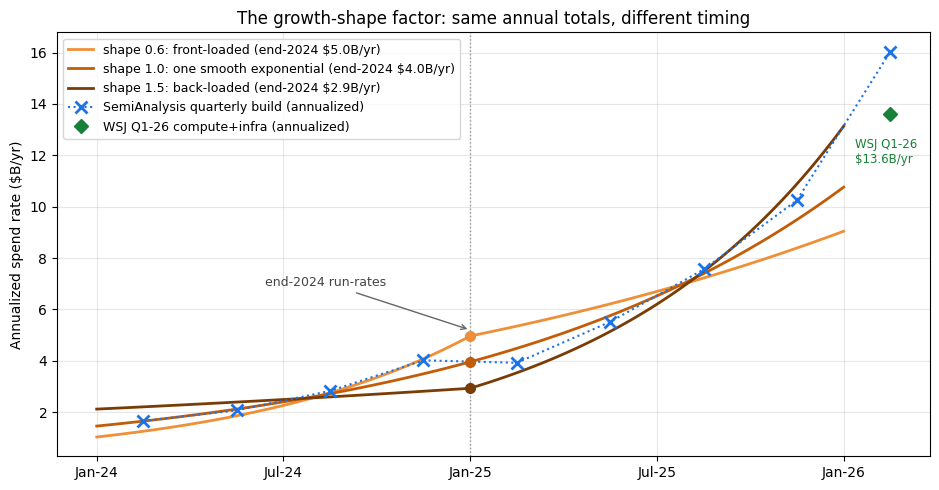

In [2]:
# SemiAnalysis's Anthropic financial model, quarterly training costs + inference
# COGS ($M), annualized at quarter midpoints. Calibrated to the same anchors
# (annual spend totals, ~1.4 GW end-2025), so it cross-checks the within-year
# shape rather than the level. Q1-2026 included for context on where the ramp
# goes next.
SA_QUARTERS = {
    2024.125: 300 + 114, 2024.375: 350 + 167, 2024.625: 400 + 306, 2024.875: 575 + 429,
    2025.125: 750 + 230, 2025.375: 950 + 429, 2025.625: 1150 + 739, 2025.875: 1400 + 1163,
    2026.125: 2054 + 1956,
}
sa_x = list(SA_QUARTERS)
sa_y = [v * 4 / 1e3 for v in SA_QUARTERS.values()]

# WSJ-reported Q1-2026 compute and infrastructure costs ($M for the quarter),
# annualized the same way. A reported figure, not a model build; its definition
# may not match SA's training + inference COGS exactly.
WSJ_Q1_2026_COSTS = 3400
wsj_x, wsj_y = 2026.125, WSJ_Q1_2026_COSTS * 4 / 1e3

# Illustration curves: the reported totals treated as exact. Each curve
# integrates to the 2024 total over 2024 and the 2025 total over 2025; the 2024
# segment gets its own growth rate, solved so its area comes out right given
# the rate it must reach at the year boundary.
ILLUS_2024_TOTAL, ILLUS_2025_TOTAL = 2.5, 6.8
illus_avg_growth = np.log(ILLUS_2025_TOTAL / ILLUS_2024_TOTAL)


def solve_2024_growth(boundary_rate):
    """Within-2024 growth rate that ends the year at the boundary rate while
    integrating to the 2024 total (bisection; the integrated fraction of the
    boundary rate falls monotonically as growth speeds up)."""
    target = ILLUS_2024_TOTAL / boundary_rate
    lo, hi = 1e-9, 20.0
    for _ in range(100):
        mid = (lo + hi) / 2
        if (1 - np.exp(-mid)) / mid > target:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2


fig, ax = plt.subplots(figsize=(9.5, 5))
t = np.linspace(0, 1, 101)
# The shape curves are one family (a swept parameter), so they share a hue as a
# light-to-dark ramp; blue and green stay reserved for the external evidence.
for shape, color, note in [(0.6, '#ef8f38', 'front-loaded'),
                           (1.0, '#c25c07', 'one smooth exponential'),
                           (1.5, '#7a3c05', 'back-loaded')]:
    growth_2025 = illus_avg_growth * shape
    # Where the 2025 exponential must start so its area is the 2025 total.
    boundary_rate = ILLUS_2025_TOTAL * growth_2025 / (np.exp(growth_2025) - 1)
    growth_2024 = solve_2024_growth(boundary_rate)
    ax.plot(2024 + t, boundary_rate * np.exp(-growth_2024 * (1 - t)), color=color, lw=2)
    ax.plot(2025 + t, boundary_rate * np.exp(growth_2025 * t), color=color, lw=2,
            label=f'shape {shape}: {note} (end-2024 ${boundary_rate:.1f}B/yr)')
    ax.plot(2025, boundary_rate, 'o', color=color, markersize=7, zorder=5)
ax.plot(sa_x, sa_y, marker='x', ls=':', color='#1a73e8', markersize=8, mew=2,
        label='SemiAnalysis quarterly build (annualized)')
ax.plot(wsj_x, wsj_y, marker='D', ls='none', color='#188038', markersize=7,
        label='WSJ Q1-26 compute+infra (annualized)')
ax.annotate(f'WSJ Q1-26\n${wsj_y:.1f}B/yr', xy=(wsj_x, wsj_y),
            xytext=(wsj_x - 0.095, wsj_y - 1.9), fontsize=8.5, color='#188038')
ax.axvline(2025, color='#999999', lw=1, ls=':')
ax.annotate('end-2024 run-rates', xy=(2025.0, 5.2), xytext=(2024.45, 6.9), fontsize=9,
            color='#444444', arrowprops=dict(arrowstyle='->', color='#666666', lw=1))
ax.set_xticks([2024, 2024.5, 2025, 2025.5, 2026])
ax.set_xticklabels(['Jan-24', 'Jul-24', 'Jan-25', 'Jul-25', 'Jan-26'])
ax.set_ylabel('Annualized spend rate ($B/yr)')
ax.set_title('The growth-shape factor: same annual totals, different timing', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Sampling the trajectory

The fitted run-rate curve is then charted against the same two reference
points; the WSJ point lands between the fitted end-2025 rate and
SemiAnalysis's steeper Q1-26 build.

In [3]:
# Priors from the sheet, sampled in the same order as the frontier script's
# model_anthropic_2024 under the same seed, so the two match exactly. (The
# spend totals are correlated in code — the sheet can't express correlations.)
sq.set_seed(42)
PARAMS = load_lab_params()['anthropic']

spend24_dist, spend25_dist = sq.correlate(
    (PARAMS['cloud_spend_2024'], PARAMS['cloud_spend_2025']), 0.5)
spend_2024_total = (spend24_dist @ N_SAMPLES) * 1e9
spend_2025_total = (spend25_dist @ N_SAMPLES) * 1e9
avg_growth = np.log(spend_2025_total / spend_2024_total)
growth_shape = PARAMS['spend_growth_shape_2025'] @ N_SAMPLES
inst_rate = avg_growth * growth_shape

# Year-end annualized run-rates of the exponential that integrates to the 2025
# total; the start-2025 rate is the end-2024 rate.
runrate_2025_end = spend_2025_total * inst_rate / (1 - np.exp(-inst_rate))
runrate_ratio = np.exp(-inst_rate)
runrate_2024_end = runrate_2025_end * runrate_ratio

print('Spending trajectory (5th / median / 95th):')
lo, mid, hi = percentiles(spend_2024_total)
print(f'   2024 full-year total ($B):        {lo / 1e9:.2f} / {mid / 1e9:.2f} / {hi / 1e9:.2f}')
lo, mid, hi = percentiles(spend_2025_total)
print(f'   2025 full-year total ($B):        {lo / 1e9:.2f} / {mid / 1e9:.2f} / {hi / 1e9:.2f}')
lo, mid, hi = percentiles(np.exp(avg_growth))
print(f'   2024->2025 avg growth factor:     {lo:.2f} / {mid:.2f} / {hi:.2f}')
lo, mid, hi = percentiles(growth_shape)
print(f'   growth shape (1 = smooth ramp):   {lo:.2f} / {mid:.2f} / {hi:.2f}')
lo, mid, hi = percentiles(runrate_2025_end)
print(f'   end-2025 spending rate ($B/yr):   {lo / 1e9:.1f} / {mid / 1e9:.1f} / {hi / 1e9:.1f}')
lo, mid, hi = percentiles(runrate_2024_end)
print(f'   end-2024 spending rate ($B/yr):   {lo / 1e9:.1f} / {mid / 1e9:.1f} / {hi / 1e9:.1f}')
lo, mid, hi = percentiles(runrate_ratio)
print(f'   => spending-rate ratio (24/25):   {lo:.2f} / {mid:.2f} / {hi:.2f}')

Spending trajectory (5th / median / 95th):
   2024 full-year total ($B):        2.19 / 2.50 / 2.84
   2025 full-year total ($B):        5.99 / 6.79 / 7.71
   2024->2025 avg growth factor:     2.39 / 2.72 / 3.09
   growth shape (1 = smooth ramp):   0.90 / 1.16 / 1.51
   end-2025 spending rate ($B/yr):   9.5 / 11.5 / 14.2
   end-2024 spending rate ($B/yr):   2.8 / 3.6 / 4.3
   => spending-rate ratio (24/25):   0.21 / 0.32 / 0.42


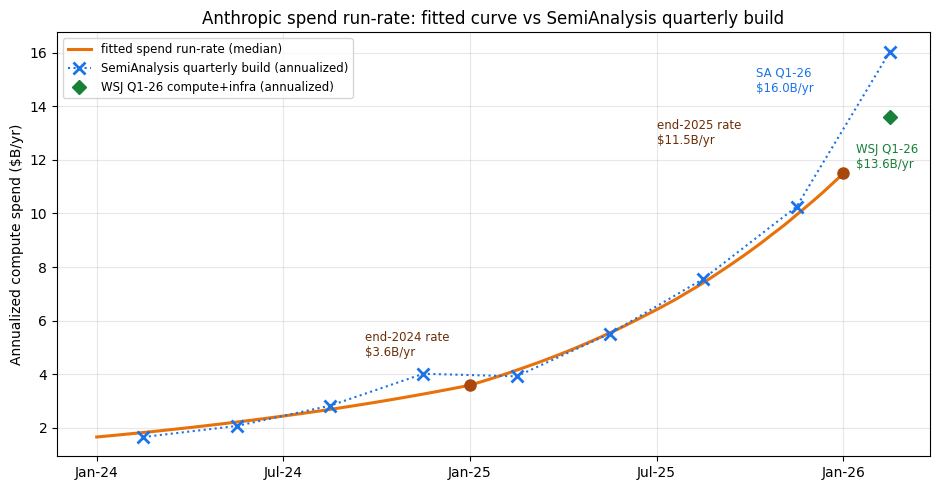

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 5))

# The fitted spend curve: over 2025, the pointwise median of the per-sample
# fitted paths (so it passes through both year-end medians); over 2024, a
# segment solved to integrate to the 2024 total, exactly as in the shape chart.
u = np.linspace(0, 1, 101)
paths = runrate_2024_end[:, None] * np.exp(np.outer(inst_rate, u))
med_path = np.median(paths, axis=0)
boundary = med_path[0]
growth_2024_fit = solve_2024_growth(boundary / 1e9)  # the solver works in $B
ax.plot(2024 + u, boundary * np.exp(-growth_2024_fit * (1 - u)) / 1e9,
        color='#e8710a', lw=2.2)
ax.plot(2025 + u, med_path / 1e9, color='#e8710a', lw=2.2,
        label='fitted spend run-rate (median)')

# The two year-end rates the backcast actually uses. The end-2025 label sits
# further left so the SemiAnalysis line rising to Q1-26 doesn't run through it.
for x, samples, label, dx in [(2025.0, runrate_2024_end, 'end-2024 rate', -0.28),
                              (2026.0, runrate_2025_end, 'end-2025 rate', -0.50)]:
    mid = float(np.median(samples))
    ax.plot(x, mid / 1e9, 'o', color='#a8480a', markersize=8, zorder=5)
    ax.annotate(f'{label}\n${mid / 1e9:.1f}B/yr', xy=(x, mid / 1e9),
                xytext=(x + dx, mid / 1e9 + 1.1), fontsize=8.5, color='#6b2e08')

ax.plot(sa_x, sa_y, marker='x', ls=':', color='#1a73e8', markersize=8, mew=2,
        label='SemiAnalysis quarterly build (annualized)')
ax.annotate(f'SA Q1-26\n${sa_y[-1]:.1f}B/yr', xy=(sa_x[-1], sa_y[-1]),
            xytext=(sa_x[-1] - 0.36, sa_y[-1] - 1.5), fontsize=8.5, color='#1a73e8')

ax.plot(wsj_x, wsj_y, marker='D', ls='none', color='#188038', markersize=7,
        label='WSJ Q1-26 compute+infra (annualized)')
ax.annotate(f'WSJ Q1-26\n${wsj_y:.1f}B/yr', xy=(wsj_x, wsj_y),
            xytext=(wsj_x - 0.09, wsj_y - 1.9), fontsize=8.5, color='#188038')

ax.set_xticks([2024, 2024.5, 2025, 2025.5, 2026])
ax.set_xticklabels(['Jan-24', 'Jul-24', 'Jan-25', 'Jul-25', 'Jan-26'])
ax.set_ylabel('Annualized compute spend ($B/yr)')
ax.set_title('Anthropic spend run-rate: fitted curve vs SemiAnalysis quarterly build', fontsize=12)
ax.legend(loc='upper left', fontsize=8.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. The mainline estimate: dollars into chips at 2024 prices

The direct conversion. A rented fleet that costs some dollar rate per
H100e-hour, billed around the clock, burns that rate × 8,760 hours per year
for each chip — so the end-2024 fleet is just the end-2024 spending rate
divided by the annual cost of one H100e.

The price: in 2024 there was no Trainium2 to buy (Project Rainier was only
announced in December 2024), so Anthropic's fleet was Hopper on long-term
contracts plus a TPU v5e slice.
[SemiAnalysis's GPU pricing index](https://semianalysis.com/gpu-pricing-index/)
puts 1-year H100 contracts at ~\$3/hr through 2023, falling to the low-\$2s
through 2024. Anthropic's effective rate should sit below that curve:
multi-year terms price at a discount to 1-year, Anthropic has scale and
pricing power with its closely tied cloud providers, and custom chips (the
TPU slice) entered the mix in 2024. But it can also sit above pure GPU-hour
pricing, because "compute spend" plausibly includes auxiliary costs — storage,
networking, CPU fleets — beyond GPU-hours. The sheet prior: **\$1.50–2.50 per
H100e-hour**.

One offsetting pair we treat as a wash: long-term contracts mean the fleet
doesn't reprice onto each quarter's cheaper deals (pushing the effective rate
up), but long-term pricing is smoother and lower to begin with (pushing it
down).

The remaining assumption: every chip is billed around the clock at the
contract rate.

In [5]:
price_2024 = PARAMS['effective_price_2024'] @ N_SAMPLES  # $ per H100e-hour

h100e_direct = runrate_2024_end / (price_2024 * HOURS_PER_YEAR)
# The canonical export; lab_2024_backcasts reads model_anthropic_2024 directly.
anthropic_2024 = h100e_direct

print('The direct conversion (5th / median / 95th):')
lo, mid, hi = percentiles(price_2024)
print(f'   2024 price ($/H100e-hr):        {lo:.2f} / {mid:.2f} / {hi:.2f}')
show('END-2024 H100e (HEADLINE)', h100e_direct)

The direct conversion (5th / median / 95th):
   2024 price ($/H100e-hr):        1.51 / 1.95 / 2.52
   END-2024 H100e (HEADLINE)         : 148k / 209k / 292k


In [6]:
# Cross-check: the canonical frontier-script function reseeds and samples the
# same priors in the same order, so it must reproduce these samples exactly.
assert np.allclose(frontier.model_anthropic_2024(), h100e_direct)
print('matches frontier_lab_compute_model.model_anthropic_2024 exactly')

matches frontier_lab_compute_model.model_anthropic_2024 exactly


## 3. Experimental cross-check: backcasting the end-2025 fleet

**Not used for the headline.** This alternative route is kept as a
validating cross-check: it anchors on the power model's end-2025 fleet
instead of 2024 prices, so agreement between the two routes is evidence the
headline isn't badly wrong, and their gap measures the tension between the
money and power anchors. It stays experimental because it chains three
multiplicative uncertain factors — so it is wider, with a long right tail
where a big fleet read, a front-loaded 2025, and a near-capped price ratio
line up — and because its extra inputs (the leaked ~1.4 GW read, the 2025
Trainium2 price structure) are judgment-heavier than the direct route's.

The idea: start from the end-2025 fleet and shrink it twice,

> end-2024 fleet = end-2025 fleet × (spending ratio) × (price ratio)

The **spending ratio** comes straight from the fitted curve in section 1:
the end-2024 rate is the end-2025 rate discounted by one year of within-2025
growth (median ~0.31).

The **price ratio** asks how much cheaper an H100e-hour was at end-2025 than
in 2024 — cheaper dollars mean the fleet shrinks *less* than spending does.
Two transparent assumptions drive it:

- **Nvidia prices fell.** Hopper rentals cheapened as Blackwell arrived, and
  Blackwell rents at better dollars-per-H100e; the 2025 Nvidia blend is
  sampled at **\$1.3–1.8 per H100e-hour** (vs \$1.50–2.50 effective in 2024).
  That is roughly the 1-year contract index's late-2025 level; 3-year terms
  price a bit cheaper, roughly counteracting the legacy-contract effect.
- **ASICs took a large share of spend.** Trainium2 is priced near Amazon's
  ~\$0.66/chip-hour cost times a **1.0–1.6× markup**; at ~0.66 H100e per
  chip that is roughly \$1.0–1.6 per H100e-hour. Its share of Anthropic's
  2025 spend is sampled at **40–70%**.

Each dollar buys compute from whichever bucket it lands in, so the blended
2025 price is the spend-weighted harmonic mix of the two bucket prices.

The 2024 effective price and the 2025 Nvidia blend are **correlated (0.5)**:
they reflect the same rental market, so a world where Anthropic's 2024 rate
was high is likelier to have pricier 2025 rentals too. This trims the tails
of the price ratio. On top of that the ratio is **capped at 0.9**: end-2025
compute was at least ~10% cheaper per H100e-hour than the 2024 effective
rate. These priors are notebook literals, not sheet rows — deliberately, as
this route is not canonical.

**The starting point** is the canonical power-based model in the frontier
script, which turns the leaked ~1.4 GW figure into chips via a
Trainium2-vs-everything-else blend of compute-per-watt. One mechanical note:
the frontier models reseed the shared random stream, so we run them here,
give the anchor samples a fixed shuffle, and draw this route's own inputs
from a different seed. That keeps the anchor and the inputs statistically
independent (fleet size and spend trajectory are separate questions).

In [7]:
openai_res = frontier.model_openai()   # Anthropic borrows Nvidia specs from this
anthropic_2025 = frontier.model_anthropic(openai_res)
anthropic_2025 = anthropic_2025[np.random.default_rng(123).permutation(N_SAMPLES)]

sq.set_seed(2024)  # this route's own draws, independent of the frontier streams

print('End-2025 anchor (canonical power model):')
show('Anthropic end-2025 H100e', anthropic_2025)

End-2025 anchor (canonical power model):
   Anthropic end-2025 H100e          : 852k / 1.18M / 1.64M


In [8]:
# This route's own 2024-price draw: the same sheet prior as the headline's,
# but drawn jointly with the 2025 Nvidia blend so the two stay correlated
# (sq.correlate ties the objects it is given, so fresh copies are loaded).
P2 = load_lab_params()['anthropic']
price_2024_r2_dist, nvidia_price_2025_dist = sq.correlate(
    (P2['effective_price_2024'], sq.to(1.3, 1.8)), 0.5)
price_2024_r2 = price_2024_r2_dist @ N_SAMPLES
nvidia_price_2025 = nvidia_price_2025_dist @ N_SAMPLES

# The two 2025 price buckets, $ per H100e-hour.
TRAINIUM2_H100E = 1299 / 1979  # dense BF16 FLOP/s ratio vs the H100
trainium_price_2025 = 0.66 * (sq.to(1.0, 1.6) @ N_SAMPLES) / TRAINIUM2_H100E
trainium_share = sq.to(0.40, 0.70) @ N_SAMPLES  # Trainium2 share of 2025 spend

# Blend by spend share: a dollar buys 1/price of compute in whichever bucket it lands.
h100e_hours_per_dollar = (
    trainium_share / trainium_price_2025 + (1 - trainium_share) / nvidia_price_2025)
price_2025 = 1 / h100e_hours_per_dollar

# Cheaper 2025 dollars mean the fleet shrank less than spending did. The cap
# rules out worlds where 2025 compute wasn't at least ~10% cheaper.
price_ratio = np.minimum(price_2025 / price_2024_r2, 0.9)
h100e_backcast = anthropic_2025 * runrate_ratio * price_ratio

print('The experimental backcast (5th / median / 95th):')
for name, arr in [('2025 Nvidia blend ($/H100e-hr)', nvidia_price_2025),
                  ('2025 Trainium2 ($/H100e-hr)', trainium_price_2025),
                  ('2025 blended price ($/H100e-hr)', price_2025),
                  ('spending ratio (end-24 / end-25)', runrate_ratio),
                  ('price ratio (2025 / 2024 price)', price_ratio)]:
    lo, mid, hi = percentiles(arr)
    print(f'   {name:33s}: {lo:.2f} / {mid:.2f} / {hi:.2f}')
show('END-2024 H100e (backcast)', h100e_backcast)

The experimental backcast (5th / median / 95th):
   2025 Nvidia blend ($/H100e-hr)   : 1.30 / 1.53 / 1.80
   2025 Trainium2 ($/H100e-hr)      : 1.01 / 1.27 / 1.60
   2025 blended price ($/H100e-hr)  : 1.17 / 1.38 / 1.60
   spending ratio (end-24 / end-25) : 0.21 / 0.32 / 0.42
   price ratio (2025 / 2024 price)  : 0.54 / 0.71 / 0.90
   END-2024 H100e (backcast)         : 148k / 259k / 436k


## 4. How the cross-check lands

The two routes share the spending trajectory and the 2024-price prior — they
differ in what anchors the *level*. The headline trusts the 2024 sticker
price; the experimental backcast trusts the power model's end-2025 fleet and
the 2025 price structure. Any gap between them is the disagreement between
"what the money should have bought" and "what the power model says Anthropic
had", carried back one year at the fitted spending ratio.

The backcast's median runs ~1.25× the headline's — equivalently, it implies
Anthropic effectively paid ~\$1.55/H100e-hr in 2024, inside (if below the
median of) the \$1.50–2.50 sticker prior. So the cross-check brackets the
headline from above rather than contradicting it; an earlier revision mixed
the two routes 50/50, which sat ~10% above the current headline.

In [9]:
print('Headline vs the experimental cross-check (5th / median / 95th):')
show('HEADLINE: direct at 2024 prices', h100e_direct)
show('experimental: backcast from end-2025', h100e_backcast)

route_gap = float(np.median(h100e_backcast)) / float(np.median(h100e_direct))
implied_price_2024 = float(np.median(runrate_2024_end)) / (
    float(np.median(h100e_backcast)) * HOURS_PER_YEAR)
print(f'\n   backcast / headline (medians): {route_gap:.2f}x')
print(f'   effective 2024 price implied by the backcast: ${implied_price_2024:.2f}/H100e-hr'
      f' (vs ${float(np.median(price_2024)):.2f} sticker prior)')

Headline vs the experimental cross-check (5th / median / 95th):
   HEADLINE: direct at 2024 prices   : 148k / 209k / 292k
   experimental: backcast from end-2025: 148k / 259k / 436k

   backcast / headline (medians): 1.24x
   effective 2024 price implied by the backcast: $1.58/H100e-hr (vs $1.95 sticker prior)


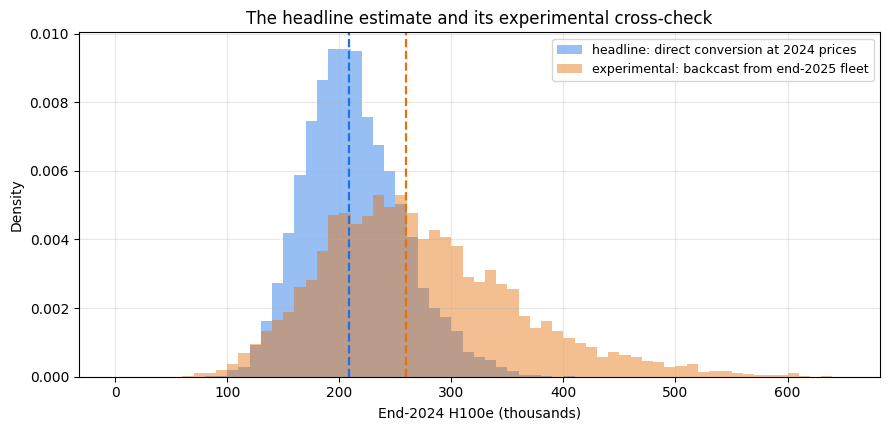

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.4))
bins = np.linspace(0, 650, 66)
for samples, color, label in [
        (h100e_direct, '#1a73e8', 'headline: direct conversion at 2024 prices'),
        (h100e_backcast, '#e8710a', 'experimental: backcast from end-2025 fleet')]:
    ax.hist(samples / 1e3, bins=bins, density=True, alpha=0.45, color=color, label=label)
    ax.axvline(float(np.median(samples)) / 1e3, color=color, lw=1.6, ls='--')
ax.set_xlabel('End-2024 H100e (thousands)')
ax.set_ylabel('Density')
ax.set_title('The headline estimate and its experimental cross-check', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# Part B: the end-2025 cloud-spend cross-check

The same dollars pointed at 2025. This is an **alternate** estimate of
Anthropic's 2025 compute, built bottom-up from cloud spend rather than from a
power figure; the canonical end-2025 model (`anthropic_power_2025`) anchors
on the leaked 1.4 GW. Starting from the **\$6.8B of 2025 cloud spend**, the
natural output is a **2025 full-year average**; section 12 rescales it to an
**end-2025 snapshot** using the year-end run-rate from section 1. The average
comes in *below* the power snapshot because the fleet grew through the year
(same gap the OpenAI spend vs. power models showed).

The fleet is split into just **two buckets** (ignoring TPU, per the brief):

- **Nvidia** — Hopper + Blackwell, using the *same* count mix and per-chip
  specs as the OpenAI model, priced at market GPU-hour **rental** rates.
- **Trainium2** — priced off SemiAnalysis's published **total cost of
  ownership of \$0.66/chip-hour**. Crucially that is *Amazon's* cost, not the
  price Amazon charges Anthropic, so an uncertain **cloud markup** goes on
  top.

The single biggest lever is how much of the spend goes to Trainium, so — like
the power notebook — we pick a central assumption and then **sweep the
Trainium share** across its full range. Priors here are notebook literals
(this part is a cross-check, not canonical).

In [11]:
BUCKET_COLORS = {'Hopper': '#76b900', 'Blackwell': '#1a73e8', 'Trainium2': '#e8710a'}
sq.set_seed(2025)  # part B's own draws, independent of parts A's streams

Generator(PCG64) at 0x16E308900

## 5. Chip specs and the Hopper:Blackwell ratio, from the OpenAI model

Exactly as the power-based Anthropic model does, we read two things off the
canonical OpenAI run (`openai_res`, computed in section 3) so the estimates
stay consistent:

- **Per-chip H100e** for the Nvidia parts.
- **OpenAI's end-2025 Hopper:Blackwell count ratio.** OpenAI also carries
  trace A100 and some GB300; we drop the A100 and fold GB300 into the
  Blackwell bucket, leaving a clean Hopper-vs-Blackwell split we reuse for
  Anthropic's Nvidia mix.

In [12]:
openai_counts = openai_res['counts']
oai_h100e = openai_res['h100e_per_gpu']  # the model calls Blackwell "B200"

# OpenAI's end-2025 Hopper vs Blackwell chip counts (median across its Monte
# Carlo), A100 dropped. This ratio is what we borrow for Anthropic's Nvidia mix.
hopper_units = float(np.median(openai_counts['H100/H200']))
blackwell_units = float(np.median(openai_counts['B200'] + openai_counts['B300']))
hopper_per_blackwell = hopper_units / blackwell_units  # Hopper chips per 1 Blackwell

# Per-chip H100e for the two Nvidia buckets; TRAINIUM2_H100E was set in section 3.
HOPPER_H100E = oai_h100e['H100/H200']
BLACKWELL_H100E = oai_h100e['B200']

print('Borrowed from OpenAI end-2025 fleet (A100 dropped, GB300 folded into Blackwell):')
print(f'   Hopper    : {HOPPER_H100E:.3f} H100e/chip')
print(f'   Blackwell : {BLACKWELL_H100E:.3f} H100e/chip')
print(f'   Hopper:Blackwell count ratio = {hopper_per_blackwell:.2f} : 1')
print(f'   Trainium2 : {TRAINIUM2_H100E:.3f} H100e/chip (independent spec)')

Borrowed from OpenAI end-2025 fleet (A100 dropped, GB300 folded into Blackwell):
   Hopper    : 1.000 H100e/chip
   Blackwell : 2.527 H100e/chip
   Hopper:Blackwell count ratio = 1.48 : 1
   Trainium2 : 0.656 H100e/chip (independent spec)


## 6. Pricing assumptions

**Nvidia (market rental, $/GPU-hour).** Same two scenarios the OpenAI spend
model uses, taken from the research summary:

- low: Hopper \$1.50, Blackwell \$3.00 (SemiAnalysis Aug-2025 3-year-contract survey)
- high: Hopper \$2.00, Blackwell \$4.00 (Silicon Data spot index, early 2026)

We treat each scenario edge as a 90% interval and **correlate** Hopper and
Blackwell (a high-price world lifts both together).

**Trainium2 ($/chip-hour).** SemiAnalysis puts the *total cost of ownership* of a
Trainium2 (Teton2-PD-Ultra-3L) cluster at **\$0.66/chip-hour** — capital plus
operating, from **Amazon's** point of view. (For reference its GB200 NVL72 TCO is
\$2.36, so on a pure-cost basis Trainium2 is far cheaper per chip-hour.) The price
Amazon actually *charges Anthropic* is TCO plus an uncertain **cloud margin**. We
model that as a markup multiplier with a 90% range of **1.0–1.6×** (median ~1.26):
the low end reflects Anthropic's unusually deep Amazon relationship (near-cost
access), the high end a more normal cloud margin.

In [13]:
TRAINIUM2_TCO = 0.66  # $/chip-hour, Amazon's cost (SemiAnalysis)

# Correlated Nvidia rental prices ($/GPU-hour).
hopper_price_dist, blackwell_price_dist = sq.correlate(
    (sq.to(1.50, 2.00), sq.to(3.00, 4.00)), 0.8)
hopper_price = hopper_price_dist @ N_SAMPLES
blackwell_price = blackwell_price_dist @ N_SAMPLES

# Trainium2 price to Anthropic = Amazon's TCO times an uncertain cloud markup.
trainium_markup = sq.to(1.0, 1.6) @ N_SAMPLES
trainium_price = TRAINIUM2_TCO * trainium_markup

print('Prices to Anthropic ($/chip-hour), 5th / median / 95th:')
for name, arr in [('Hopper', hopper_price), ('Blackwell', blackwell_price),
                  ('Trainium2', trainium_price)]:
    lo, mid, hi = percentiles(arr)
    print(f'   {name:10s}: {lo:.2f} / {mid:.2f} / {hi:.2f}')

Prices to Anthropic ($/chip-hour), 5th / median / 95th:
   Hopper    : 1.50 / 1.73 / 2.00
   Blackwell : 2.99 / 3.48 / 4.01
   Trainium2 : 0.66 / 0.84 / 1.06


### What a dollar buys in each bucket

The whole model turns on **H100e bought per dollar of annual spend**, which is
just the per-chip H100e divided by a year of rental cost (`price × 8760`). This
is where Trainium's advantage — and its dependence on the markup — shows up. At a
near-cost markup Trainium buys clearly more H100e per dollar than Nvidia; at a
full cloud margin the advantage mostly disappears, consistent with the summary's
"non-Nvidia cheaper per dollar, but well under 2×."

In [14]:
def h100e_per_dollar_year(per_chip_h100e, price_per_hour):
    """H100e bought per $1 of annual spend on a chip rented all year."""
    return per_chip_h100e / (price_per_hour * HOURS_PER_YEAR)


# Express per $1B/year so the numbers are readable.
buckets_per_b = {
    'Hopper': h100e_per_dollar_year(HOPPER_H100E, hopper_price) * 1e9,
    'Blackwell': h100e_per_dollar_year(BLACKWELL_H100E, blackwell_price) * 1e9,
    'Trainium2': h100e_per_dollar_year(TRAINIUM2_H100E, trainium_price) * 1e9,
}
print('H100e per $1B of annual spend (5th / median / 95th):')
for name, arr in buckets_per_b.items():
    lo, mid, hi = percentiles(arr)
    print(f'   {name:10s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

H100e per $1B of annual spend (5th / median / 95th):
   Hopper    : 57k / 66k / 76k
   Blackwell : 72k / 83k / 97k
   Trainium2 : 71k / 89k / 113k


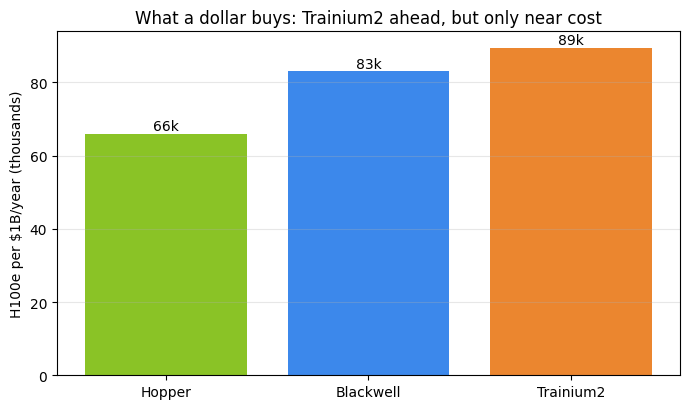

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.2))
medians = {name: np.median(arr) for name, arr in buckets_per_b.items()}
ax.bar(list(medians), [v / 1e3 for v in medians.values()],
       color=[BUCKET_COLORS[n] for n in medians], alpha=0.85)
for col, value in enumerate(medians.values()):
    ax.text(col, value / 1e3 + 1, f'{value / 1e3:,.0f}k', ha='center', fontsize=10)
ax.set_ylabel('H100e per $1B/year (thousands)')
ax.set_title('What a dollar buys: Trainium2 ahead, but only near cost', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. Spend: reuse the section-1 trajectory

Part A already sampled everything this needs, from the sheet priors: the
correlated 2024/2025 full-year totals and the year-end run-rate under the
growth-shape factor. (When this cross-check was a standalone notebook it drew
its own copies with a wider 0.6–1.6 shape prior; merging unified them on the
canonical 0.9–1.5.) Sections 8–11 feed in the 2025 *total* and give a
full-year average; section 12 feeds in the *year-end run-rate* for the
snapshot.

In [16]:
spend = spend_2025_total        # sections 8-11: the full-year average
spend_2025_end = runrate_2025_end  # section 12: the end-2025 snapshot

lo, mid, hi = percentiles(spend)
print(f'2025 full-year total ($B):    {lo / 1e9:.2f} / {mid / 1e9:.2f} / {hi / 1e9:.2f}')
lo, mid, hi = percentiles(spend_2025_end)
print(f'End-2025 annualized run-rate: {lo / 1e9:.2f} / {mid / 1e9:.2f} / {hi / 1e9:.2f}')
print(f'   year-end / full-year average: {np.median(spend_2025_end) / np.median(spend):.2f}x (median)')

2025 full-year total ($B):    5.99 / 6.79 / 7.71
End-2025 annualized run-rate: 9.48 / 11.49 / 14.21
   year-end / full-year average: 1.69x (median)


## 8. The model

Split the spend into a Trainium2 slice and an Nvidia slice by the **Trainium
share of spend**. Within the Nvidia slice, split between Hopper and Blackwell so
the resulting *chip counts* keep OpenAI's borrowed Hopper:Blackwell ratio — given
that ratio and the two prices, the dollar split is pinned. Each slice then
converts dollars to an annual-average chip count (`dollars ÷ price ÷ 8760`) and
on to H100e.

In [17]:
# With a Hopper:Blackwell count ratio of r:1 and per-hour prices, the share of
# Nvidia dollars going to Hopper is fixed (r Hoppers cost r*price_H, one Blackwell
# costs price_B). This varies per sample because prices do.
hopper_spend_share = (hopper_per_blackwell * hopper_price) / (
    hopper_per_blackwell * hopper_price + blackwell_price)


def anthropic_spend_h100e(total_spend, trainium_spend_share):
    """Annual-average H100e by bucket for the given spend (array) and Trainium2
    share of spend (scalar). Returns per-bucket H100e arrays plus totals."""
    trainium_spend = total_spend * trainium_spend_share
    nvidia_spend = total_spend * (1 - trainium_spend_share)

    # Trainium2 slice.
    trainium_chips = trainium_spend / trainium_price / HOURS_PER_YEAR
    trainium_h100e = trainium_chips * TRAINIUM2_H100E

    # Nvidia slice, split into Hopper and Blackwell.
    hopper_chips = nvidia_spend * hopper_spend_share / hopper_price / HOURS_PER_YEAR
    blackwell_chips = nvidia_spend * (1 - hopper_spend_share) / blackwell_price / HOURS_PER_YEAR
    hopper_h100e = hopper_chips * HOPPER_H100E
    blackwell_h100e = blackwell_chips * BLACKWELL_H100E

    chips = {'Hopper': hopper_chips, 'Blackwell': blackwell_chips, 'Trainium2': trainium_chips}
    h100e = {'Hopper': hopper_h100e, 'Blackwell': blackwell_h100e, 'Trainium2': trainium_h100e}
    return {
        'chips': chips,
        'h100e': h100e,
        'total_chips': sum(chips.values()),
        'total_h100e': sum(h100e.values()),
    }

## 9. Central estimate and the Trainium-share sweep

**Central assumption: Trainium2 takes ~55% of the spend.** Trainium is the
largest single piece of Anthropic's fleet (Project Rainier plus the Mississippi
campus), but it is cheaper per chip-hour, so its *dollar* share sits a bit below
its *compute* share. We report the full distribution at 55% and then sweep the
share from 0 to 90%.

In [18]:
CENTRAL_TRAINIUM_SHARE = 0.55
central = anthropic_spend_h100e(spend, CENTRAL_TRAINIUM_SHARE)

lo, mid, hi = percentiles(central['total_h100e'])
print(f'Central estimate at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2 spend share '
      f'(2025 full-year average H100e):')
print(f'   5th / median / 95th = {fmt(lo)} / {fmt(mid)} / {fmt(hi)}\n')
print('   Median H100e by bucket:')
for name in ('Hopper', 'Blackwell', 'Trainium2'):
    print(f'      {name:10s}: {fmt(np.median(central["h100e"][name]))}')

Central estimate at 55% Trainium2 spend share (2025 full-year average H100e):
   5th / median / 95th = 468k / 568k / 693k

   Median H100e by bucket:
      Hopper    : 86k
      Blackwell : 146k
      Trainium2 : 336k


In [19]:
sweep_shares = np.round(np.arange(0.0, 0.901, 0.05), 2)
table_shares = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
sweep = {share: anthropic_spend_h100e(spend, share) for share in sweep_shares}

print(f'{"Trainium2 spend share":>22}   {"H100e (5th / median / 95th)":>30}')
print('-' * 58)
for share in table_shares:
    lo, mid, hi = percentiles(sweep[share]['total_h100e'])
    print(f'{share * 100:>20.0f}%   {fmt(lo):>9} /{fmt(mid):>9} /{fmt(hi):>9}')

 Trainium2 spend share      H100e (5th / median / 95th)
----------------------------------------------------------
                   0%        428k /     515k /     620k
                  10%        440k /     525k /     627k
                  20%        451k /     535k /     636k
                  30%        458k /     545k /     648k
                  40%        463k /     554k /     664k
                  50%        467k /     564k /     683k
                  60%        470k /     573k /     703k
                  70%        471k /     583k /     724k
                  80%        470k /     591k /     748k
                  90%        469k /     601k /     772k


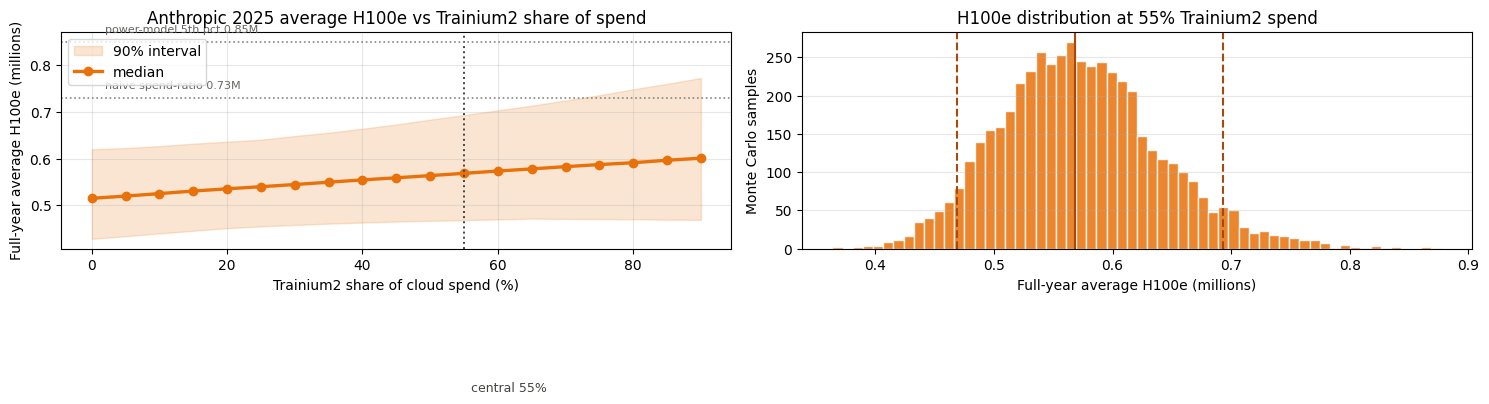

In [20]:
fig, (ax_curve, ax_hist) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: H100e across the Trainium2 spend-share sweep, with the 90% band.
median_curve = np.array([np.median(sweep[s]['total_h100e']) for s in sweep_shares]) / 1e6
low_curve = np.array([percentiles(sweep[s]['total_h100e'])[0] for s in sweep_shares]) / 1e6
high_curve = np.array([percentiles(sweep[s]['total_h100e'])[2] for s in sweep_shares]) / 1e6

ax_curve.fill_between(sweep_shares * 100, low_curve, high_curve, color='#e8710a', alpha=0.18,
                      label='90% interval')
ax_curve.plot(sweep_shares * 100, median_curve, color='#e8710a', lw=2.4, marker='o', label='median')
ax_curve.axvline(CENTRAL_TRAINIUM_SHARE * 100, color='#444441', ls=':', lw=1.4)
ax_curve.text(CENTRAL_TRAINIUM_SHARE * 100 + 1, median_curve[0] * 0.2,
              'central 55%', fontsize=9, color='#444441')

# Outside anchors, for orientation: the naive spend-ratio scaling and the power
# model's end-2025 5th percentile (~0.85M after the 7/30 prior widening).
for value, text in [(0.73, 'naive spend-ratio 0.73M'), (0.85, 'power-model 5th pct 0.85M')]:
    ax_curve.axhline(value, color='#888780', ls=':', lw=1.2)
    ax_curve.text(2, value + 0.02, text, fontsize=8, color='#666560')

ax_curve.set_title('Anthropic 2025 average H100e vs Trainium2 share of spend', fontsize=12)
ax_curve.set_xlabel('Trainium2 share of cloud spend (%)')
ax_curve.set_ylabel('Full-year average H100e (millions)')
ax_curve.legend(loc='upper left')
ax_curve.grid(True, alpha=0.3)

# Right: the H100e distribution at the central share.
ax_hist.hist(central['total_h100e'] / 1e6, bins=60, color='#e8710a', alpha=0.85, edgecolor='white')
for value, style in zip(percentiles(central['total_h100e']), ['--', '-', '--']):
    ax_hist.axvline(value / 1e6, color='#a8480a', ls=style, lw=1.5)
ax_hist.set_title(f'H100e distribution at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2 spend', fontsize=12)
ax_hist.set_xlabel('Full-year average H100e (millions)')
ax_hist.set_ylabel('Monte Carlo samples')
ax_hist.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10. Cross-check: implied Trainium2 chip count

Each spend share implies an annual-average Trainium2 chip count. The bottom-up
evidence — Project Rainier (~700k Trainium2 by end-2025) plus the Mississippi
campus — points to several hundred thousand Trainium2 chips, though those are
*year-end* figures while this model is a *full-year average*, so the average
should sit somewhat lower.

In [21]:
print(f'{"Trainium2 spend share":>22} {"Total H100e (median)":>20} {"Trainium2 chips (median)":>26}')
print('-' * 72)
for share in table_shares:
    total_med = np.median(sweep[share]['total_h100e'])
    trainium_chips_med = np.median(sweep[share]['chips']['Trainium2'])
    print(f'{share * 100:>20.0f}%   {fmt(total_med):>17}   {fmt(trainium_chips_med):>23}')

 Trainium2 spend share Total H100e (median)   Trainium2 chips (median)
------------------------------------------------------------------------
                   0%                515k                        0k
                  10%                525k                       93k
                  20%                535k                      186k
                  30%                545k                      279k
                  40%                554k                      372k
                  50%                564k                      465k
                  60%                573k                      558k
                  70%                583k                      651k
                  80%                591k                      744k
                  90%                601k                      837k


## 11. What drives the uncertainty

At the central share, turn each random input on alone (others held at their
median) to see which spreads the full-year H100e the most.

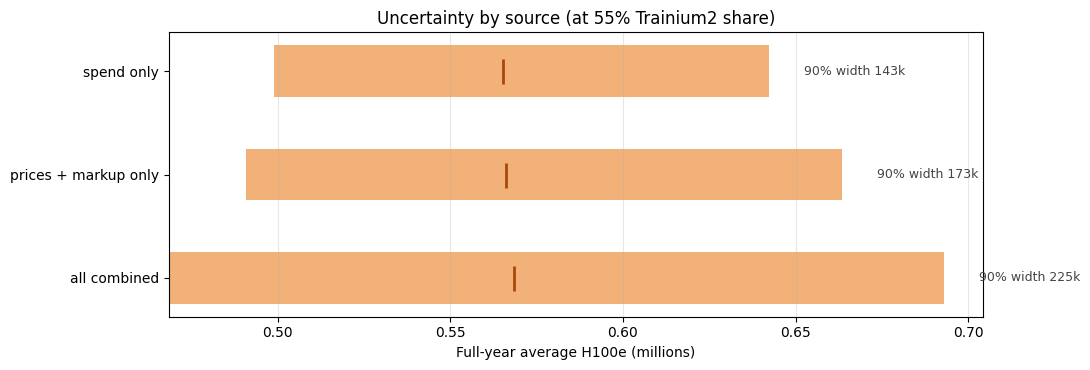

Full-year average H100e by source (5th / median / 95th):
   spend only              : 499k / 565k / 642k
   prices + markup only    : 491k / 566k / 664k
   all combined            : 468k / 568k / 693k


In [22]:
median_spend = float(np.median(spend))


def with_fixed_prices():
    """H100e at the central share with prices/markup held at their medians, so
    only spend varies."""
    global hopper_price, blackwell_price, trainium_price, hopper_spend_share
    saved = (hopper_price, blackwell_price, trainium_price, hopper_spend_share)
    hopper_price = np.full(N_SAMPLES, np.median(saved[0]))
    blackwell_price = np.full(N_SAMPLES, np.median(saved[1]))
    trainium_price = np.full(N_SAMPLES, np.median(saved[2]))
    hopper_spend_share = (hopper_per_blackwell * hopper_price) / (
        hopper_per_blackwell * hopper_price + blackwell_price)
    out = anthropic_spend_h100e(spend, CENTRAL_TRAINIUM_SHARE)
    hopper_price, blackwell_price, trainium_price, hopper_spend_share = saved
    return out


def with_fixed_spend():
    """H100e at the central share with spend held at its median, so only
    prices/markup vary."""
    return anthropic_spend_h100e(np.full(N_SAMPLES, median_spend), CENTRAL_TRAINIUM_SHARE)


decomposition = {
    'spend only': with_fixed_prices(),
    'prices + markup only': with_fixed_spend(),
    'all combined': central,
}

fig, ax = plt.subplots(figsize=(11, 3.8))
sources = list(decomposition)
for row, name in enumerate(sources):
    lo, mid, hi = percentiles(decomposition[name]['total_h100e'])
    ax.barh(row, (hi - lo) / 1e6, left=lo / 1e6, color='#e8710a', alpha=0.55, height=0.5)
    ax.plot(mid / 1e6, row, marker='|', color='#a8480a', markersize=18, markeredgewidth=2)
    ax.text((hi) / 1e6 + 0.01, row, f'90% width {fmt(hi - lo)}', va='center', fontsize=9, color='#444441')
ax.set_yticks(range(len(sources)))
ax.set_yticklabels(sources)
ax.invert_yaxis()
ax.set_xlabel('Full-year average H100e (millions)')
ax.set_title(f'Uncertainty by source (at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2 share)', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Full-year average H100e by source (5th / median / 95th):')
for name in sources:
    lo, mid, hi = percentiles(decomposition[name]['total_h100e'])
    print(f'   {name:24s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

## 12. End-2025 snapshot: plug in the year-end run-rate

Sections 8–11 used the full-year total and gave an *average*. Feeding the
**end-2025 annualized run-rate** (section 1) through the very same model
instead gives an **end-2025 snapshot** — the apples-to-apples comparison with
the power model's year-end figure. Because the model is linear in spend, this
is just the average scaled up by the year-end-to-average ratio, but running
it through keeps the full uncertainty (now including the growth shape)
attached.

In [23]:
central_end = anthropic_spend_h100e(spend_2025_end, CENTRAL_TRAINIUM_SHARE)
sweep_end = {share: anthropic_spend_h100e(spend_2025_end, share) for share in sweep_shares}

lo, mid, hi = percentiles(central_end['total_h100e'])
print(f'End-2025 SNAPSHOT at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2 spend share:')
print(f'   5th / median / 95th = {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')
avg_mid = np.median(central['total_h100e'])
print(f'   (vs full-year average median {fmt(avg_mid)} from section 9)\n')

print(f'{"Trainium2 spend share":>22}   {"End-2025 snapshot H100e (5th / median / 95th)":>30}')
print('-' * 62)
for share in table_shares:
    lo, mid, hi = percentiles(sweep_end[share]['total_h100e'])
    print(f'{share * 100:>20.0f}%   {fmt(lo):>9} /{fmt(mid):>9} /{fmt(hi):>9}')

End-2025 SNAPSHOT at 55% Trainium2 spend share:
   5th / median / 95th = 753k / 962k / 1.25M
   (vs full-year average median 568k from section 9)

 Trainium2 spend share   End-2025 snapshot H100e (5th / median / 95th)
--------------------------------------------------------------
                   0%        683k /     872k /    1.12M
                  10%        703k /     888k /    1.14M
                  20%        718k /     905k /    1.16M
                  30%        732k /     921k /    1.18M
                  40%        743k /     938k /    1.21M
                  50%        751k /     953k /    1.23M
                  60%        755k /     970k /    1.27M
                  70%        759k /     984k /    1.31M
                  80%        762k /    1.00M /    1.34M
                  90%        761k /    1.02M /    1.38M


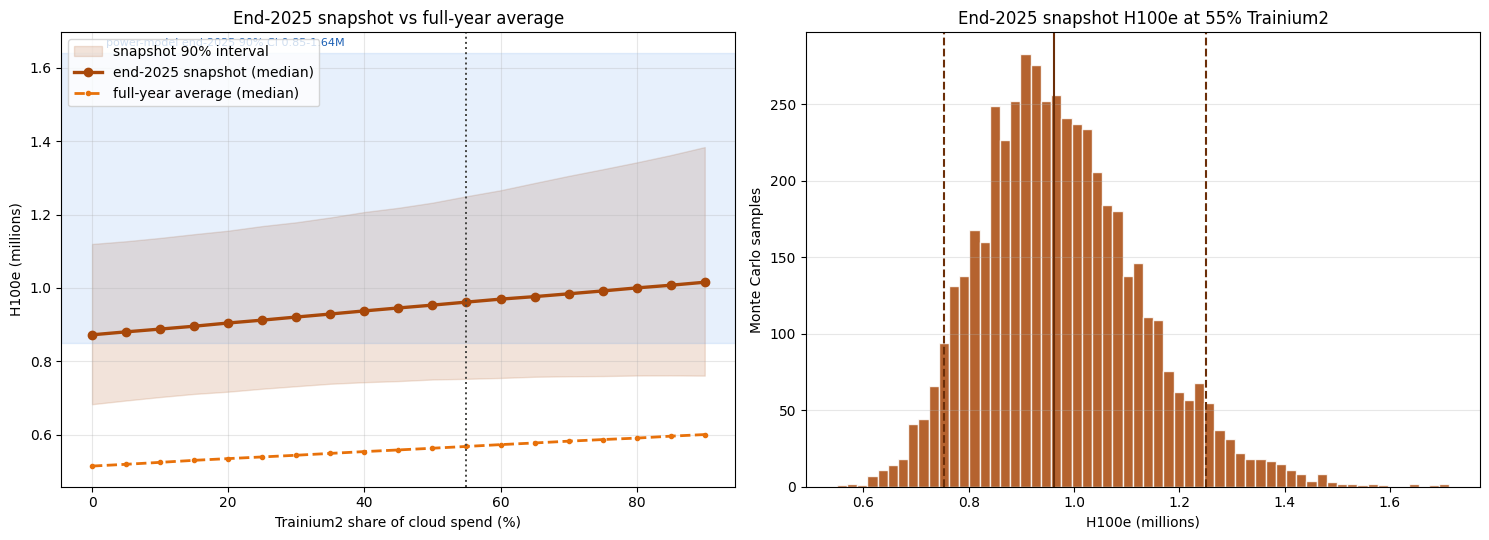

In [24]:
fig, (ax_curve, ax_hist) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: average vs end-2025 snapshot across the Trainium share sweep.
avg_med = np.array([np.median(sweep[s]['total_h100e']) for s in sweep_shares]) / 1e6
end_med = np.array([np.median(sweep_end[s]['total_h100e']) for s in sweep_shares]) / 1e6
end_lo = np.array([percentiles(sweep_end[s]['total_h100e'])[0] for s in sweep_shares]) / 1e6
end_hi = np.array([percentiles(sweep_end[s]['total_h100e'])[2] for s in sweep_shares]) / 1e6

ax_curve.fill_between(sweep_shares * 100, end_lo, end_hi, color='#a8480a', alpha=0.15,
                      label='snapshot 90% interval')
ax_curve.plot(sweep_shares * 100, end_med, color='#a8480a', lw=2.4, marker='o', label='end-2025 snapshot (median)')
ax_curve.plot(sweep_shares * 100, avg_med, color='#e8710a', lw=2.0, ls='--', marker='.',
              label='full-year average (median)')
# Power-model end-2025 90% CI, for orientation (0.85-1.64M after 7/30 widening).
ax_curve.axhspan(0.85, 1.64, color='#1a73e8', alpha=0.10)
ax_curve.text(2, 1.66, 'power-model end-2025 90% CI 0.85-1.64M', fontsize=8, color='#1a5fb4')
ax_curve.axvline(CENTRAL_TRAINIUM_SHARE * 100, color='#444441', ls=':', lw=1.4)
ax_curve.set_title('End-2025 snapshot vs full-year average', fontsize=12)
ax_curve.set_xlabel('Trainium2 share of cloud spend (%)')
ax_curve.set_ylabel('H100e (millions)')
ax_curve.legend(loc='upper left')
ax_curve.grid(True, alpha=0.3)

# Right: snapshot distribution at the central share.
ax_hist.hist(central_end['total_h100e'] / 1e6, bins=60, color='#a8480a', alpha=0.85, edgecolor='white')
for value, style in zip(percentiles(central_end['total_h100e']), ['--', '-', '--']):
    ax_hist.axvline(value / 1e6, color='#6b2e08', ls=style, lw=1.5)
ax_hist.set_title(f'End-2025 snapshot H100e at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2', fontsize=12)
ax_hist.set_xlabel('H100e (millions)')
ax_hist.set_ylabel('Monte Carlo samples')
ax_hist.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Takeaways

**Part A (canonical end-2024):** ~209k H100e (90% CI ~148k–292k) from the
direct conversion; the experimental power backcast lands ~1.24× higher and
brackets it from above.

**Part B (end-2025 cross-check):**

- **Two outputs from the same dollars.** The 2025 *full-year average*
  describes the year as a whole; the *end-2025 snapshot* describes the fleet
  at year-end, after the spend ramp. The snapshot is the right number to set
  beside the power model's year-end figure.
- **The snapshot lands inside the power model's CI.** Scaling the average up
  by the year-end run-rate puts it in the lower half of the power model's
  0.85–1.64M band — the two methods are roughly consistent once put on the
  same (year-end) footing.
- **The Trainium markup is the hidden swing factor.** Because Trainium is
  priced off Amazon's \$0.66 cost, whether Anthropic pays near cost or a full
  cloud margin changes how much compute each Trainium dollar buys — amplified
  by a bigger Trainium share.
- This stays a rough alternate. The cleanest ways to tighten it are a better
  Trainium markup estimate, a firmer Trainium-share figure (via the
  chip-count cross-check), and a within-year (e.g. quarterly) spend figure to
  pin the growth shape instead of perturbing it.